# 🧠 The Mind of a Model
# Day 5: Model Evaluation

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

print('✅ Libraries imported!')

✅ Libraries imported!


In [ ]:
url = 'https://raw.githubusercontent.com/Aeshwa-Kachhadiya/The-mind-of-a-model/main/dataset/linkedin_post_performance.xlsx'

df = pd.read_excel(url)
print('✅ Dataset loaded!')
print(f'Shape: {df.shape}')

✅ Dataset loaded!
Shape: (300, 20)


In [ ]:
binary_cols = ['has_image', 'has_video', 'has_carousel',
               'has_hashtags', 'has_question', 'has_emoji',
               'is_weekend']

for col in binary_cols:
    df[col] = df[col].map({'Yes': 1, 'No': 0})

print('✅ Binary columns encoded!')

✅ Binary columns encoded!


In [ ]:
df['went_viral'] = df['went_viral'].map({'Yes': 1, 'No': 0})

print('✅ Target variable encoded!')

✅ Target variable encoded!


In [ ]:
le = LabelEncoder()
df['topic_category'] = le.fit_transform(df['topic_category'])
df['posting_day'] = le.fit_transform(df['posting_day'])

print('✅ Categorical columns encoded!')

✅ Categorical columns encoded!


In [ ]:
numerical_cols = ['word_count', 'account_followers',
                  'account_age_months', 'posting_frequency',
                  'likes_first_hour', 'comments_first_hour',
                  'shares_first_hour', 'impressions_first_hour']

for col in numerical_cols:
    df[col].fillna(df[col].median(), inplace=True)

print('✅ Missing values handled!')

✅ Missing values handled!


/tmp/ipykernel_3851/2647236093.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)


In [ ]:
X = df.drop(columns=['went_viral'])
y = df['went_viral']

print(f'Features shape: {X.shape}')
print(f'Target shape: {y.shape}')

Features shape: (300, 19)
Target shape: (300,)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Training set: {X_train.shape[0]} rows')
print(f'Testing set: {X_test.shape[0]} rows')

Training set: 240 rows
Testing set: 60 rows


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

print('✅ Model libraries imported!')

✅ Model libraries imported!


In [ ]:
lr_model = LogisticRegression(random_state=42, max_iter=1000)
dt_model = DecisionTreeClassifier(random_state=42)
rf_model = RandomForestClassifier(random_state=42)
xgb_model = XGBClassifier(random_state=42,
                           eval_metric='logloss',
                           verbosity=0)

lr_model.fit(X_train, y_train)
dt_model.fit(X_train, y_train)
rf_model.fit(X_train, y_train)
xgb_model.fit(X_train, y_train)

models = {
    'Logistic Regression': lr_model,
    'Decision Tree': dt_model,
    'Random Forest': rf_model,
    'XGBoost': xgb_model
}

print('✅ All models trained!')

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


✅ All models trained!


In [ ]:
from sklearn.metrics import accuracy_score

print('ACCURACY SCORES:')
print()
for name, model in models.items():
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f'{name}: {acc:.2%}')

ACCURACY SCORES:

Logistic Regression: 81.67%
Decision Tree: 90.00%
Random Forest: 85.00%
XGBoost: 88.33%


In [ ]:
from sklearn.metrics import classification_report

print('CLASSIFICATION REPORT — Random Forest:')
print()
y_pred_rf = rf_model.predict(X_test)
print(classification_report(y_test, y_pred_rf,
      target_names=['Not Viral', 'Viral']))

CLASSIFICATION REPORT — Random Forest:

              precision    recall  f1-score   support

   Not Viral       0.83      0.97      0.90        40
       Viral       0.92      0.60      0.73        20

    accuracy                           0.85        60
   macro avg       0.88      0.79      0.81        60
weighted avg       0.86      0.85      0.84        60



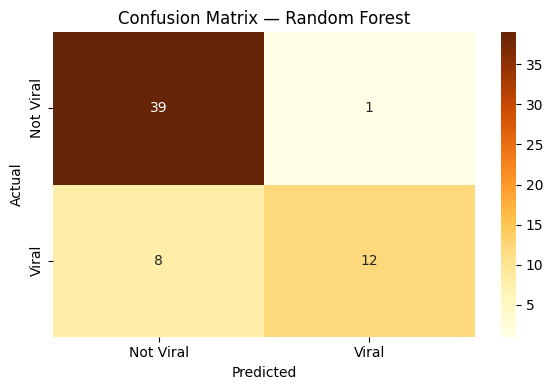

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

y_pred_rf = rf_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d',
            cmap='YlOrBr',
            xticklabels=['Not Viral', 'Viral'],
            yticklabels=['Not Viral', 'Viral'])
plt.title('Confusion Matrix — Random Forest')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

print('PRECISION, RECALL, F1 — All Models:')
print()

for name, model in models.items():
    y_pred = model.predict(X_test)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    print(f'{name}:')
    print(f'  Precision : {precision:.2%}')
    print(f'  Recall    : {recall:.2%}')
    print(f'  F1 Score  : {f1:.2%}')
    print()

PRECISION, RECALL, F1 — All Models:

Logistic Regression:
  Precision : 76.47%
  Recall    : 65.00%
  F1 Score  : 70.27%

Decision Tree:
  Precision : 93.75%
  Recall    : 75.00%
  F1 Score  : 83.33%

Random Forest:
  Precision : 92.31%
  Recall    : 60.00%
  F1 Score  : 72.73%

XGBoost:
  Precision : 88.24%
  Recall    : 75.00%
  F1 Score  : 81.08%



ROC AUC SCORES:

Logistic Regression: 0.88
Decision Tree: 0.86
Random Forest: 0.93
XGBoost: 0.93


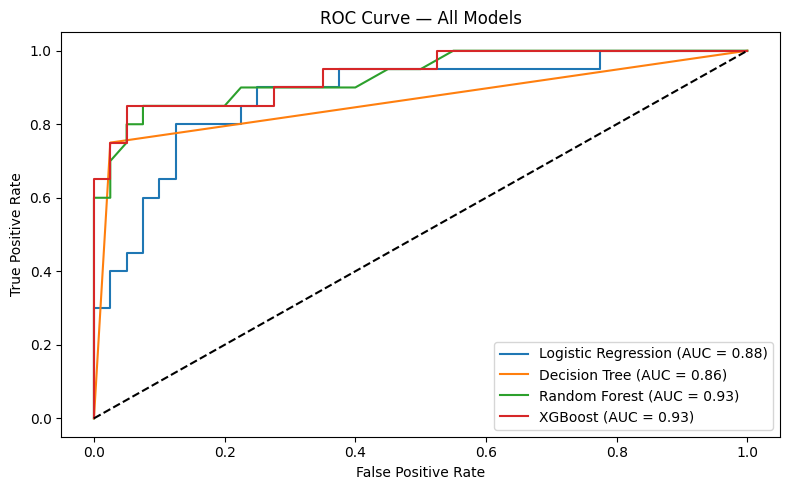

In [ ]:
from sklearn.metrics import roc_auc_score, roc_curve

print('ROC AUC SCORES:')
print()

plt.figure(figsize=(8, 5))

for name, model in models.items():
    y_prob = model.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, y_prob)
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.2f})')
    print(f'{name}: {auc:.2f}')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — All Models')
plt.legend()
plt.tight_layout()
plt.show()